# TurboQuant — Small Dimension Walkthrough

This notebook traces **every single number** through the TurboQuant algorithm using tiny vectors (d=4).
No magic — just matrix multiplications you can follow by hand.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
plt.rcParams['font.size'] = 11

## Step 0: Our Tiny Vector

We'll work with **d=4** so you can see every number.
Start with a random unit vector (normalized to length 1).

Our vector x = [ 0.9234  0.3078 -0.1026  0.2052]
Length ||x|| = 1.0000
Dimension d  = 4



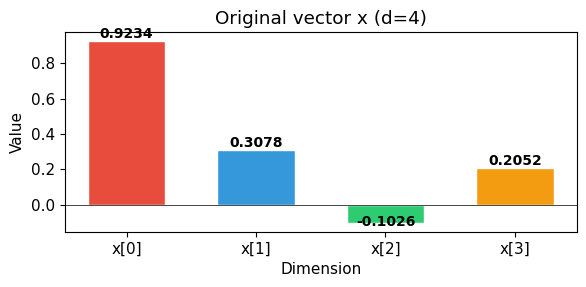

In [3]:
d = 4
x = np.array([0.9, 0.3, -0.1, 0.2])
x = x / np.linalg.norm(x)  # normalize to unit length

print(f"Our vector x = {x}")
print(f"Length ||x|| = {np.linalg.norm(x):.4f}")
print(f"Dimension d  = {d}")
print()

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax.bar(range(d), x, color=colors, edgecolor='white', width=0.6)
for i, v in enumerate(x):
    ax.text(i, v + 0.02 * np.sign(v), f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Dimension')
ax.set_ylabel('Value')
ax.set_title('Original vector x (d=4)')
ax.set_xticks(range(d))
ax.set_xticklabels([f'x[{i}]' for i in range(d)])
plt.tight_layout()
plt.show()

---
## Step 1: Generate Random Rotation Matrix Π

We create a 4×4 orthogonal matrix using QR decomposition of a random Gaussian matrix.

**Key property**: Π preserves lengths and angles. It just "spins" the vector.

Random rotation matrix Π (4×4):
[[-0.6519  0.2767  0.2415 -0.6634]
 [ 0.3073 -0.3002  0.8974 -0.1006]
 [ 0.6162 -0.0278 -0.3018 -0.727 ]
 [-0.3176 -0.9124 -0.2129 -0.1459]]

Verification: Π^T @ Π = I ?
[[ 1. -0. -0.  0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1. -0.]
 [ 0.  0. -0.  1.]]
  ✓ Identity matrix (off-diagonal ≈ 0)



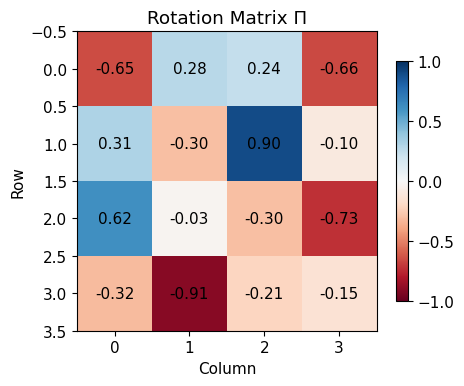

In [4]:
# Generate random rotation matrix
G = np.random.randn(d, d)
Pi, _ = np.linalg.qr(G)

print("Random rotation matrix Π (4×4):")
print(Pi)
print()

# Verify it's orthogonal: Π^T @ Π should be identity
print("Verification: Π^T @ Π = I ?")
print(Pi.T @ Pi)
print("  ✓ Identity matrix (off-diagonal ≈ 0)")
print()

# Visualize the rotation matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(Pi, cmap='RdBu', vmin=-1, vmax=1)
for i in range(d):
    for j in range(d):
        ax.text(j, i, f'{Pi[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Rotation Matrix Π')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## Step 2: Rotate the Vector → y = Π · x

This is just a matrix-vector multiplication. The rotated vector **y** has the same length as **x**,
but its coordinates are "scrambled" — spread more evenly.

ROTATION: y = Π @ x
  x = [ 0.9234  0.3078 -0.1026  0.2052]
  y = [-0.6777  0.0787  0.4422 -0.5822]

  ||x|| = 1.0000
  ||y|| = 1.0000  ← same! Length preserved.

How each y[i] is computed (dot product of row i of Π with x):
  y[0] = (-0.6519)×(+0.9234) + (+0.2767)×(+0.3078) + (+0.2415)×(-0.1026) + (-0.6634)×(+0.2052) = -0.6777
  y[1] = (+0.3073)×(+0.9234) + (-0.3002)×(+0.3078) + (+0.8974)×(-0.1026) + (-0.1006)×(+0.2052) = +0.0787
  y[2] = (+0.6162)×(+0.9234) + (-0.0278)×(+0.3078) + (-0.3018)×(-0.1026) + (-0.7270)×(+0.2052) = +0.4422
  y[3] = (-0.3176)×(+0.9234) + (-0.9124)×(+0.3078) + (-0.2129)×(-0.1026) + (-0.1459)×(+0.2052) = -0.5822


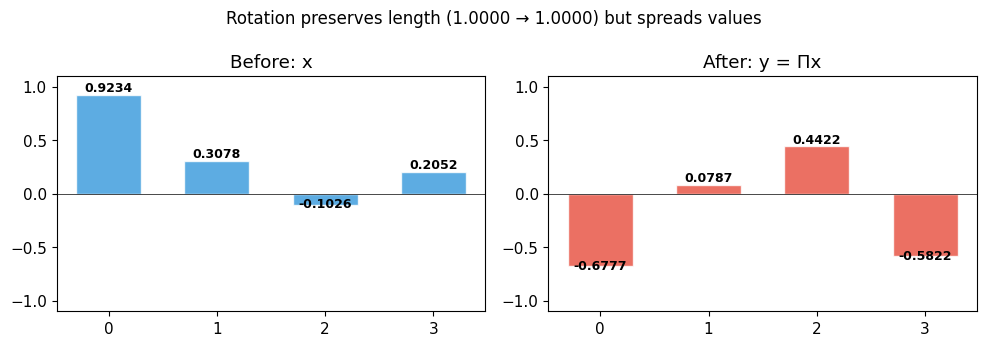

In [5]:
y = Pi @ x

print("ROTATION: y = Π @ x")
print(f"  x = {x}")
print(f"  y = {y}")
print()
print(f"  ||x|| = {np.linalg.norm(x):.4f}")
print(f"  ||y|| = {np.linalg.norm(y):.4f}  ← same! Length preserved.")
print()

# Show the computation step by step
print("How each y[i] is computed (dot product of row i of Π with x):")
for i in range(d):
    terms = ' + '.join([f'({Pi[i,j]:+.4f})×({x[j]:+.4f})' for j in range(d)])
    print(f"  y[{i}] = {terms} = {y[i]:+.4f}")

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, vec, title, c in [(axes[0], x, 'Before: x', '#3498db'), 
                           (axes[1], y, 'After: y = Πx', '#e74c3c')]:
    bars = ax.bar(range(d), vec, color=c, edgecolor='white', width=0.6, alpha=0.8)
    for i, v in enumerate(vec):
        ax.text(i, v + 0.03 * np.sign(v), f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)
    ax.set_xticks(range(d))

plt.suptitle(f'Rotation preserves length ({np.linalg.norm(x):.4f} → {np.linalg.norm(y):.4f}) but spreads values', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 3: Compute Optimal Centroids (Lloyd-Max)

For d=4, the Gaussian approximation has σ = 1/√4 = 0.5.

We'll use **b=2 bits** → 4 centroids (each coordinate becomes one of 4 values).

In [6]:

b = 2  # 2 bits per coordinate
n_levels = 2**b  # = 4 allowed values
sigma = 1 / np.sqrt(d)  # = 0.5 for d=4
centroids = np.linspace(-3*sigma, 3*sigma, n_levels)
centroids

array([-1.5, -0.5,  0.5,  1.5])

Parameters: d=4, b=2 bits, σ = 1/√4 = 0.5000
Number of centroids: 4

Optimal centroids (the 4 allowed values):
  c[0] = -0.7552   (stored as index 0, which is 00 in binary)
  c[1] = -0.2264   (stored as index 1, which is 01 in binary)
  c[2] = +0.2264   (stored as index 2, which is 10 in binary)
  c[3] = +0.7552   (stored as index 3, which is 11 in binary)

Decision boundaries (where you switch from one centroid to the next):
  boundary[0] = -inf
  boundary[1] = -0.4908
  boundary[2] = -0.0000
  boundary[3] = +0.4908
  boundary[4] = inf


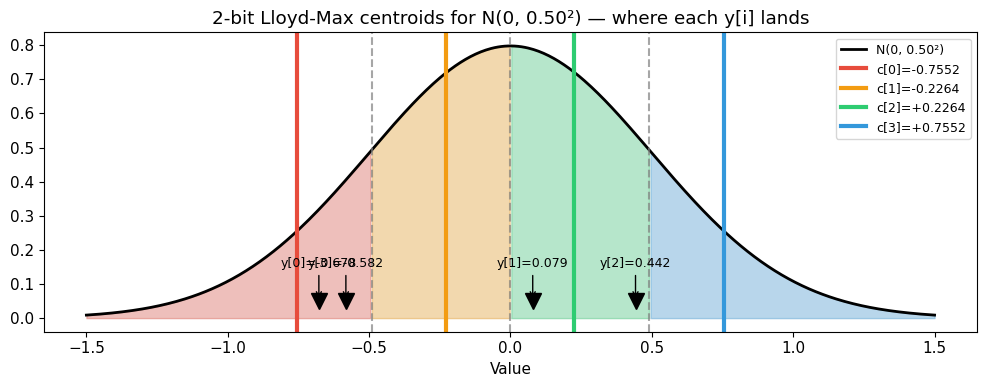

In [7]:
def lloyd_max_gaussian(n_levels, sigma, max_iter=200):
    """Lloyd-Max quantizer for N(0, sigma^2)."""
    centroids = np.linspace(-3*sigma, 3*sigma, n_levels)
    for _ in range(max_iter):
        boundaries = np.concatenate([[-np.inf],
                                      (centroids[:-1] + centroids[1:]) / 2,
                                      [np.inf]])
        new_centroids = np.zeros_like(centroids)
        for i in range(n_levels):
            lo, hi = boundaries[i], boundaries[i+1]
            num = sigma * (norm.pdf(lo/sigma) - norm.pdf(hi/sigma))
            den = norm.cdf(hi/sigma) - norm.cdf(lo/sigma)
            if den > 1e-15:
                new_centroids[i] = num / den
            else:
                new_centroids[i] = (lo + hi) / 2
        if np.allclose(centroids, new_centroids, atol=1e-12):
            break
        centroids = new_centroids
    return centroids, boundaries


b = 2  # 2 bits per coordinate
n_levels = 2**b  # = 4 allowed values
sigma = 1 / np.sqrt(d)  # = 0.5 for d=4

centroids, boundaries = lloyd_max_gaussian(n_levels, sigma)

print(f"Parameters: d={d}, b={b} bits, σ = 1/√{d} = {sigma:.4f}")
print(f"Number of centroids: {n_levels}")
print()
print("Optimal centroids (the 4 allowed values):")
for i, c in enumerate(centroids):
    print(f"  c[{i}] = {c:+.4f}   (stored as index {i}, which is {i:02b} in binary)")
print()
print("Decision boundaries (where you switch from one centroid to the next):")
for i, bd in enumerate(boundaries):
    print(f"  boundary[{i}] = {bd:+.4f}" if np.isfinite(bd) else f"  boundary[{i}] = {bd}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
xx = np.linspace(-3*sigma, 3*sigma, 500)
pdf = norm.pdf(xx, 0, sigma)
ax.plot(xx, pdf, 'k-', lw=2, label=f'N(0, {sigma:.2f}²)')
ax.fill_between(xx, pdf, alpha=0.1, color='gray')

cmap = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
for i in range(n_levels):
    lo = max(boundaries[i], xx[0])
    hi = min(boundaries[i+1], xx[-1])
    mask = (xx >= lo) & (xx <= hi)
    ax.fill_between(xx[mask], pdf[mask], alpha=0.3, color=cmap[i])
    ax.axvline(centroids[i], color=cmap[i], lw=3, ls='-', label=f'c[{i}]={centroids[i]:+.4f}')

for bd in boundaries[1:-1]:
    ax.axvline(bd, color='gray', lw=1.5, ls='--', alpha=0.7)

# Mark where y values fall
for i, yi in enumerate(y):
    ax.plot(yi, 0.05, 'v', markersize=12, color='black', zorder=5)
    ax.annotate(f'y[{i}]={yi:.3f}', xy=(yi, 0.05), xytext=(yi, 0.15),
                fontsize=9, ha='center', arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title(f'2-bit Lloyd-Max centroids for N(0, {sigma:.2f}²) — where each y[i] lands')
ax.set_xlabel('Value')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

---
## Step 4: Quantize — Snap Each y[i] to Nearest Centroid

Each coordinate of y gets replaced by its nearest centroid.
We store the **index** (0, 1, 2, or 3) — that's just 2 bits per coordinate.

QUANTIZATION: snap each y[i] to the nearest centroid
  y[0] = -0.6777
    Distances to centroids: |-0.6777 - (-0.7552)| = 0.0775, |-0.6777 - (-0.2264)| = 0.4513, |-0.6777 - (+0.2264)| = 0.9041, |-0.6777 - (+0.7552)| = 1.4330
    → Nearest: c[0] = -0.7552
    → Store index: 0 (binary: 00)

  y[1] = +0.0787
    Distances to centroids: |+0.0787 - (-0.7552)| = 0.8339, |+0.0787 - (-0.2264)| = 0.3051, |+0.0787 - (+0.2264)| = 0.1477, |+0.0787 - (+0.7552)| = 0.6766
    → Nearest: c[2] = +0.2264
    → Store index: 2 (binary: 10)

  y[2] = +0.4422
    Distances to centroids: |+0.4422 - (-0.7552)| = 1.1974, |+0.4422 - (-0.2264)| = 0.6686, |+0.4422 - (+0.2264)| = 0.2158, |+0.4422 - (+0.7552)| = 0.3130
    → Nearest: c[2] = +0.2264
    → Store index: 2 (binary: 10)

  y[3] = -0.5822
    Distances to centroids: |-0.5822 - (-0.7552)| = 0.1730, |-0.5822 - (-0.2264)| = 0.3558, |-0.5822 - (+0.2264)| = 0.8086, |-0.5822 - (+0.7552)| = 1.3374
    → Nearest: c[0] = -0.7552
    → Store index: 0 (binary: 00)


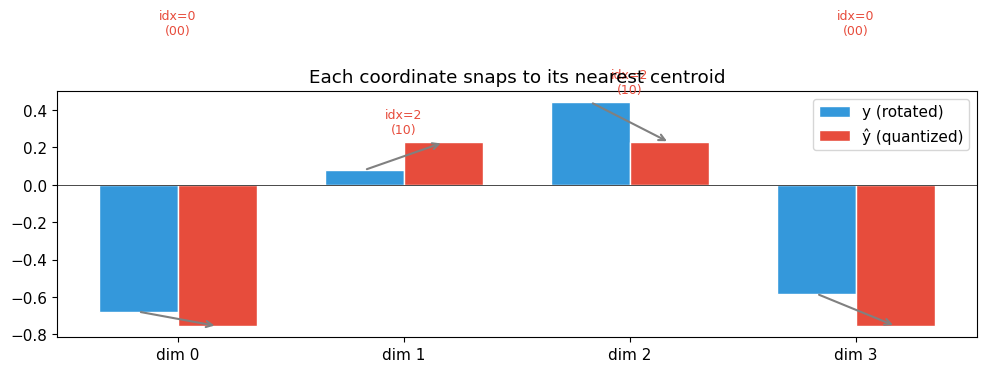

(array([0, 2, 2, 0]), array([-0.7552,  0.2264,  0.2264, -0.7552]))

In [9]:
# Find nearest centroid for each coordinate
indices = np.searchsorted(boundaries[1:-1], y)
y_quantized = centroids[indices]

print("QUANTIZATION: snap each y[i] to the nearest centroid")
print("=" * 65)
for i in range(d):
    dists = [f'|{y[i]:+.4f} - ({centroids[j]:+.4f})| = {abs(y[i]-centroids[j]):.4f}' for j in range(n_levels)]
    print(f"  y[{i}] = {y[i]:+.4f}")
    print(f"    Distances to centroids: {', '.join(dists)}")
    print(f"    → Nearest: c[{indices[i]}] = {centroids[indices[i]]:+.4f}")
    print(f"    → Store index: {indices[i]} (binary: {indices[i]:02b})")
    print()

print(f"Stored indices: {indices}  (each is {b} bits)")
print(f"Total storage: {d} coordinates × {b} bits = {d*b} bits")
print(f"Original storage: {d} coordinates × 32 bits = {d*32} bits")
print(f"Compression: {d*32}/{d*b} = {32/b:.0f}x")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(d)
width = 0.35
ax.bar(x_pos - width/2, y, width, label='y (rotated)', color='#3498db', edgecolor='white')
ax.bar(x_pos + width/2, y_quantized, width, label='ŷ (quantized)', color='#e74c3c', edgecolor='white')

for i in range(d):
    ax.annotate('', xy=(i + width/2, y_quantized[i]),
                xytext=(i - width/2, y[i]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(i, max(abs(y[i]), abs(y_quantized[i])) + 0.05,
            f'idx={indices[i]}\n({indices[i]:02b})', ha='center', fontsize=9, color='#e74c3c')

ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'dim {i}' for i in range(d)])
ax.set_title('Each coordinate snaps to its nearest centroid')
ax.legend()
plt.tight_layout()
plt.show() 

---
## Step 5: Dequantize — Rotate Back → x̃ = Πᵀ · ŷ

To reconstruct the original vector, we look up the centroids from the indices,
then multiply by Πᵀ (the inverse rotation) to go back to the original coordinate system.

DEQUANTIZATION
Step 1: Look up centroids from indices [0 2 2 0]
  ŷ = [-0.7552  0.2264  0.2264 -0.7552]

Step 2: Rotate back: x̃ = Πᵀ @ ŷ
  x̃ = [0.9413 0.4059 0.1132 0.4239]

Compare with original:
  x  = [ 0.9234  0.3078 -0.1026  0.2052]
  x̃  = [0.9413 0.4059 0.1132 0.4239]
  error = x - x̃ = [-0.0179 -0.0981 -0.2158 -0.2187]

  MSE = 0.026086
  ||x̃|| = 1.1150  (close to 1.0 but not exact)


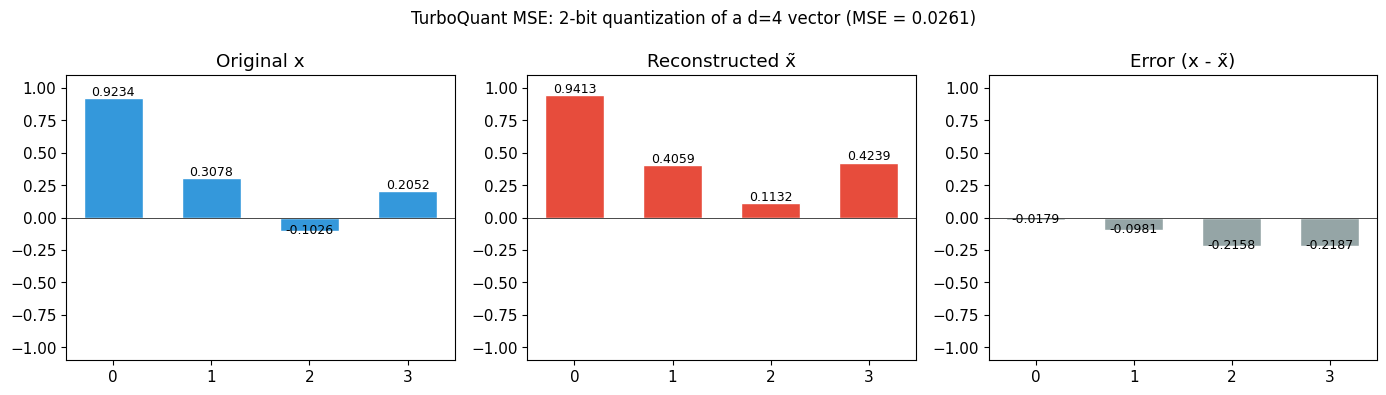

In [10]:
# Dequantize
y_hat = centroids[indices]  # look up centroids from stored indices
x_hat = Pi.T @ y_hat       # rotate back

print("DEQUANTIZATION")
print("=" * 50)
print(f"Step 1: Look up centroids from indices {indices}")
print(f"  ŷ = {y_hat}")
print()
print(f"Step 2: Rotate back: x̃ = Πᵀ @ ŷ")
print(f"  x̃ = {x_hat}")
print()
print(f"Compare with original:")
print(f"  x  = {x}")
print(f"  x̃  = {x_hat}")
print(f"  error = x - x̃ = {x - x_hat}")
print()
mse = np.mean((x - x_hat)**2)
print(f"  MSE = {mse:.6f}")
print(f"  ||x̃|| = {np.linalg.norm(x_hat):.4f}  (close to 1.0 but not exact)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vec, title, color in [
    (axes[0], x, 'Original x', '#3498db'),
    (axes[1], x_hat, 'Reconstructed x̃', '#e74c3c'),
    (axes[2], x - x_hat, 'Error (x - x̃)', '#95a5a6')]:
    bars = ax.bar(range(d), vec, color=color, edgecolor='white', width=0.6)
    for i, v in enumerate(vec):
        ax.text(i, v + 0.02 * np.sign(v), f'{v:.4f}', ha='center', fontsize=9)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_xticks(range(d))
    ax.set_ylim(-1.1, 1.1)

plt.suptitle(f'TurboQuant MSE: {b}-bit quantization of a d={d} vector (MSE = {mse:.4f})', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 6: The Full MSE Pipeline — All Steps on One Page

Let's trace the entire flow in a single visual.

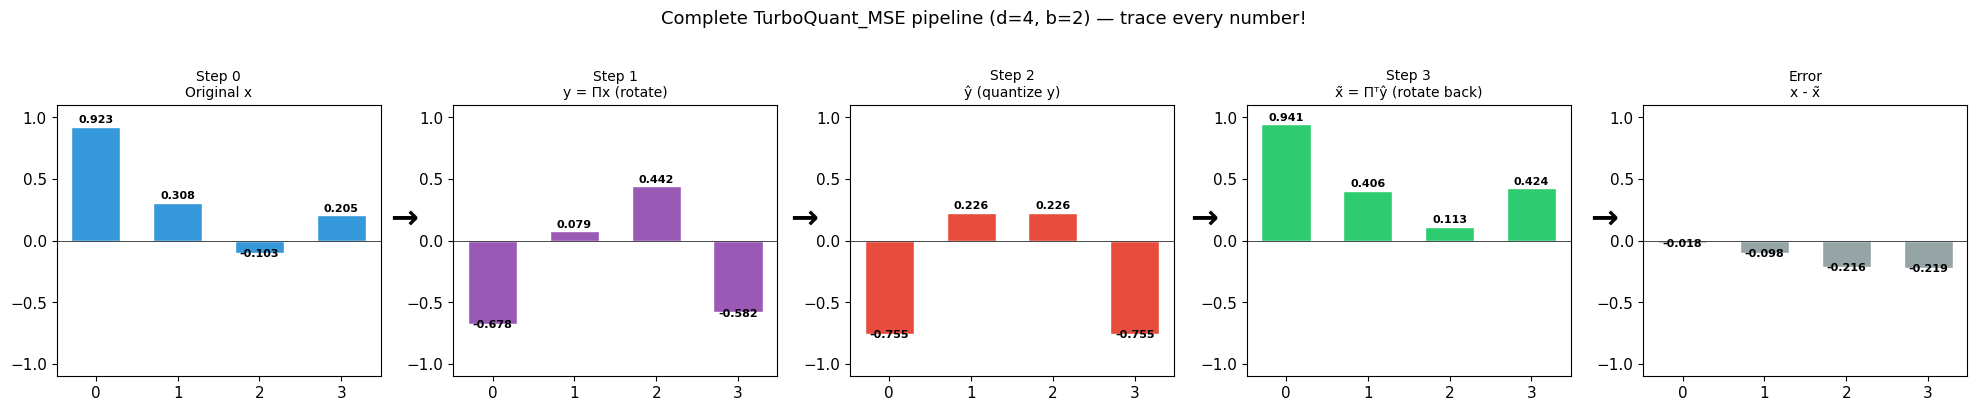

Summary:
  Original:    x  = [ 0.9234  0.3078 -0.1026  0.2052] (128 bits as float32)
  Rotated:     y  = [-0.6777  0.0787  0.4422 -0.5822]
  Quantized:   ŷ  = [-0.7552  0.2264  0.2264 -0.7552]  (stored as indices [0 2 2 0] = 8 bits)
  Reconstructed: x̃ = [0.9413 0.4059 0.1132 0.4239]
  MSE = 0.026086 | Compression = 16x


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

data = [
    (x,           'Step 0\nOriginal x',        '#3498db'),
    (y,           'Step 1\ny = Πx (rotate)',    '#9b59b6'),
    (y_hat,       'Step 2\nŷ (quantize y)',     '#e74c3c'),
    (x_hat,       'Step 3\nx̃ = Πᵀŷ (rotate back)', '#2ecc71'),
    (x - x_hat,   'Error\nx - x̃',              '#95a5a6'),
]

for ax, (vec, title, color) in zip(axes, data):
    ax.bar(range(d), vec, color=color, edgecolor='white', width=0.6)
    for i, v in enumerate(vec):
        ax.text(i, v + 0.03 * np.sign(v), f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(d))
    ax.set_ylim(-1.1, 1.1)

# Add arrows between plots
for i in range(4):
    fig.text(0.2 * (i + 1) + 0.01, 0.5, '→', fontsize=24, ha='center', va='center', fontweight='bold')

plt.suptitle(f'Complete TurboQuant_MSE pipeline (d={d}, b={b}) — trace every number!', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Original:    x  = {x} (128 bits as float32)")
print(f"  Rotated:     y  = {y}")
print(f"  Quantized:   ŷ  = {y_hat}  (stored as indices {indices} = {d*b} bits)")
print(f"  Reconstructed: x̃ = {x_hat}")
print(f"  MSE = {mse:.6f} | Compression = {32/b:.0f}x")

---
## Step 7: Inner Products — Seeing the Bias

Now let's check: if we compute dot products using the quantized vector x̃,
how close are they to the true dot products with x?

With a small example first, then with many trials to see the pattern.

In [12]:
# A single concrete example
q = np.array([0.5, -0.3, 0.7, 0.1])
q = q / np.linalg.norm(q)

true_ip = np.dot(q, x)
est_ip = np.dot(q, x_hat)

print("INNER PRODUCT EXAMPLE")
print("=" * 50)
print(f"Query:   q = {q}")
print(f"Original: x = {x}")
print(f"Quantized: x̃ = {x_hat}")
print()
print(f"True inner product:      ⟨q, x⟩  = ", end="")
terms = [f'({q[i]:.4f})×({x[i]:.4f})' for i in range(d)]
print(f"{' + '.join(terms)} = {true_ip:.4f}")
print()
print(f"Estimated inner product: ⟨q, x̃⟩ = ", end="")
terms = [f'({q[i]:.4f})×({x_hat[i]:.4f})' for i in range(d)]
print(f"{' + '.join(terms)} = {est_ip:.4f}")
print()
print(f"Error: {est_ip - true_ip:+.4f}  ({(est_ip/true_ip - 1)*100:+.1f}%)")

INNER PRODUCT EXAMPLE
Query:   q = [ 0.5455 -0.3273  0.7638  0.1091]
Original: x = [ 0.9234  0.3078 -0.1026  0.2052]
Quantized: x̃ = [0.9413 0.4059 0.1132 0.4239]

True inner product:      ⟨q, x⟩  = (0.5455)×(0.9234) + (-0.3273)×(0.3078) + (0.7638)×(-0.1026) + (0.1091)×(0.2052) = 0.3470

Estimated inner product: ⟨q, x̃⟩ = (0.5455)×(0.9413) + (-0.3273)×(0.4059) + (0.7638)×(0.1132) + (0.1091)×(0.4239) = 0.5134

Error: +0.1663  (+47.9%)


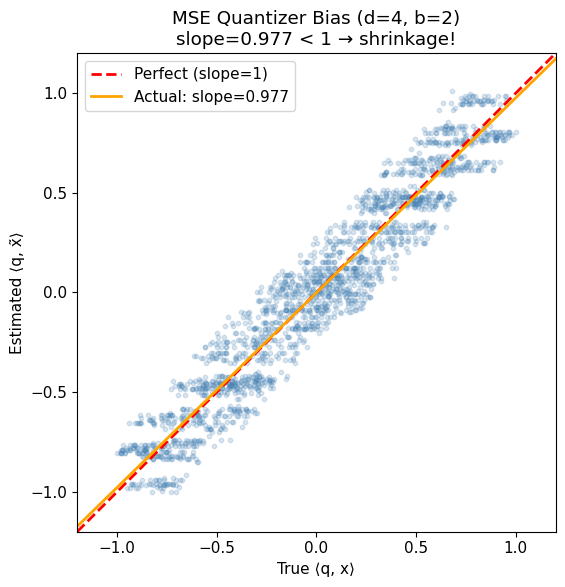

Slope = 0.9771 (should be 1.0 for unbiased)
This means dot products are systematically SHRUNK by 2.3%


In [13]:
# Many trials to see the bias pattern
n_trials = 2000
true_ips = []
est_ips = []

for _ in range(n_trials):
    # Random database vector
    xi = np.random.randn(d)
    xi = xi / np.linalg.norm(xi)
    
    # Quantize it
    yi = Pi @ xi
    idx_i = np.searchsorted(boundaries[1:-1], yi)
    yi_hat = centroids[idx_i]
    xi_hat = Pi.T @ yi_hat
    
    # Compute inner products with a fixed query
    true_ips.append(np.dot(q, xi))
    est_ips.append(np.dot(q, xi_hat))

true_ips = np.array(true_ips)
est_ips = np.array(est_ips)
coeffs = np.polyfit(true_ips, est_ips, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_ips, est_ips, alpha=0.2, s=10, color='steelblue')
lim = 1.2
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=2, label='Perfect (slope=1)')
ax.plot([-lim, lim], [coeffs[0]*(-lim)+coeffs[1], coeffs[0]*lim+coeffs[1]],
        'orange', lw=2, label=f'Actual: slope={coeffs[0]:.3f}')
ax.set_xlabel('True ⟨q, x⟩')
ax.set_ylabel('Estimated ⟨q, x̃⟩')
ax.set_title(f'MSE Quantizer Bias (d={d}, b={b})\nslope={coeffs[0]:.3f} < 1 → shrinkage!')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Slope = {coeffs[0]:.4f} (should be 1.0 for unbiased)")
print(f"This means dot products are systematically SHRUNK by {(1-coeffs[0])*100:.1f}%")

---
## Step 8: TurboQuant_Prod — The Two-Stage Fix

Now the full inner-product-optimized version. Let's trace every step.

### Stage 1: MSE quantize with (b-1) = 1 bit
### Stage 2: QJL on the residual with 1 bit

In [14]:
b_prod = 2  # total bits
b_mse = b_prod - 1  # = 1 bit for MSE stage

print("=" * 60)
print(f"TurboQuant_Prod: {b_prod} total bits = {b_mse} bit MSE + 1 bit QJL")
print("=" * 60)

# --- STAGE 1: MSE quantize with 1 bit ---
n_levels_mse = 2**b_mse  # = 2 centroids
centroids_1bit, boundaries_1bit = lloyd_max_gaussian(n_levels_mse, sigma)

print(f"\n--- STAGE 1: MSE with {b_mse} bit ({n_levels_mse} centroids) ---")
print(f"1-bit centroids: {centroids_1bit}")
print(f"  (Just 2 values: negative side and positive side)")

# Rotate
y_s1 = Pi @ x
print(f"\nRotate: y = Π @ x = {y_s1}")

# Quantize with 1 bit
idx_s1 = np.searchsorted(boundaries_1bit[1:-1], y_s1)
y_hat_s1 = centroids_1bit[idx_s1]
print(f"1-bit quantize: indices = {idx_s1}")
print(f"  ŷ_mse = {y_hat_s1}")

# Reconstruct MSE part
x_mse = Pi.T @ y_hat_s1
print(f"\nRotate back: x̃_mse = Πᵀ @ ŷ_mse = {x_mse}")

# Compute residual
r = x - x_mse
gamma = np.linalg.norm(r)
print(f"\nResidual: r = x - x̃_mse = {r}")
print(f"  ||r|| = {gamma:.4f}  (this measures how much error is left)")

TurboQuant_Prod: 2 total bits = 1 bit MSE + 1 bit QJL

--- STAGE 1: MSE with 1 bit (2 centroids) ---
1-bit centroids: [-0.3989  0.3989]
  (Just 2 values: negative side and positive side)

Rotate: y = Π @ x = [-0.6777  0.0787  0.4422 -0.5822]
1-bit quantize: indices = [0 1 1 0]
  ŷ_mse = [-0.3989  0.3989  0.3989 -0.3989]

Rotate back: x̃_mse = Πᵀ @ ŷ_mse = [ 0.7552  0.1228  0.2262 -0.0073]

Residual: r = x - x̃_mse = [ 0.1682  0.185  -0.3288  0.2125]
  ||r|| = 0.4645  (this measures how much error is left)


In [15]:
# --- STAGE 2: QJL on the residual ---
print("--- STAGE 2: QJL (1-bit) on the residual ---")
print()

# Generate random projection matrix S
S = np.random.randn(d, d)
print(f"Random projection matrix S ({d}×{d}):")
print(S)

# Project the residual
Sr = S @ r
print(f"\nProject residual: S @ r = {Sr}")

# Take the sign (1-bit quantization)
qjl = np.sign(Sr)
print(f"Take sign:     sign(S@r) = {qjl}")
print(f"  (Each value is +1 or -1 → just 1 bit each!)")

# Reconstruct QJL correction
scale = gamma * np.sqrt(np.pi / 2) / d
x_qjl = scale * (S.T @ qjl)
print(f"\nQJL correction: ||r|| × √(π/2) / d × Sᵀ @ qjl")
print(f"  = {gamma:.4f} × {np.sqrt(np.pi/2):.4f} / {d} × Sᵀ @ qjl")
print(f"  = {scale:.4f} × Sᵀ @ qjl")
print(f"  = {x_qjl}")

# Final reconstruction
x_prod = x_mse + x_qjl
print(f"\n--- FINAL RESULT ---")
print(f"x̃ = x̃_mse + correction")
print(f"   = {x_mse}")
print(f"   + {x_qjl}")
print(f"   = {x_prod}")
print(f"\nOriginal: {x}")
print(f"MSE of TurboQuant_Prod: {np.mean((x - x_prod)**2):.6f}")

--- STAGE 2: QJL (1-bit) on the residual ---

Random projection matrix S (4×4):
[[-0.7329 -0.7402  2.121   0.9778]
 [-2.3851 -0.5653 -1.812  -0.9507]
 [-3.1385 -0.137  -1.1419  0.0599]
 [-1.6251  0.0829 -0.4149  1.502 ]]

Project residual: S @ r = [-0.7498 -0.1119 -0.165   0.1976]
Take sign:     sign(S@r) = [-1. -1. -1.  1.]
  (Each value is +1 or -1 → just 1 bit each!)

QJL correction: ||r|| × √(π/2) / d × Sᵀ @ qjl
  = 0.4645 × 1.2533 / 4 × Sᵀ @ qjl
  = 0.1455 × Sᵀ @ qjl
  = [0.6741 0.222  0.0608 0.2059]

--- FINAL RESULT ---
x̃ = x̃_mse + correction
   = [ 0.7552  0.1228  0.2262 -0.0073]
   + [0.6741 0.222  0.0608 0.2059]
   = [1.4293 0.3448 0.287  0.1987]

Original: [ 0.9234  0.3078 -0.1026  0.2052]
MSE of TurboQuant_Prod: 0.102283


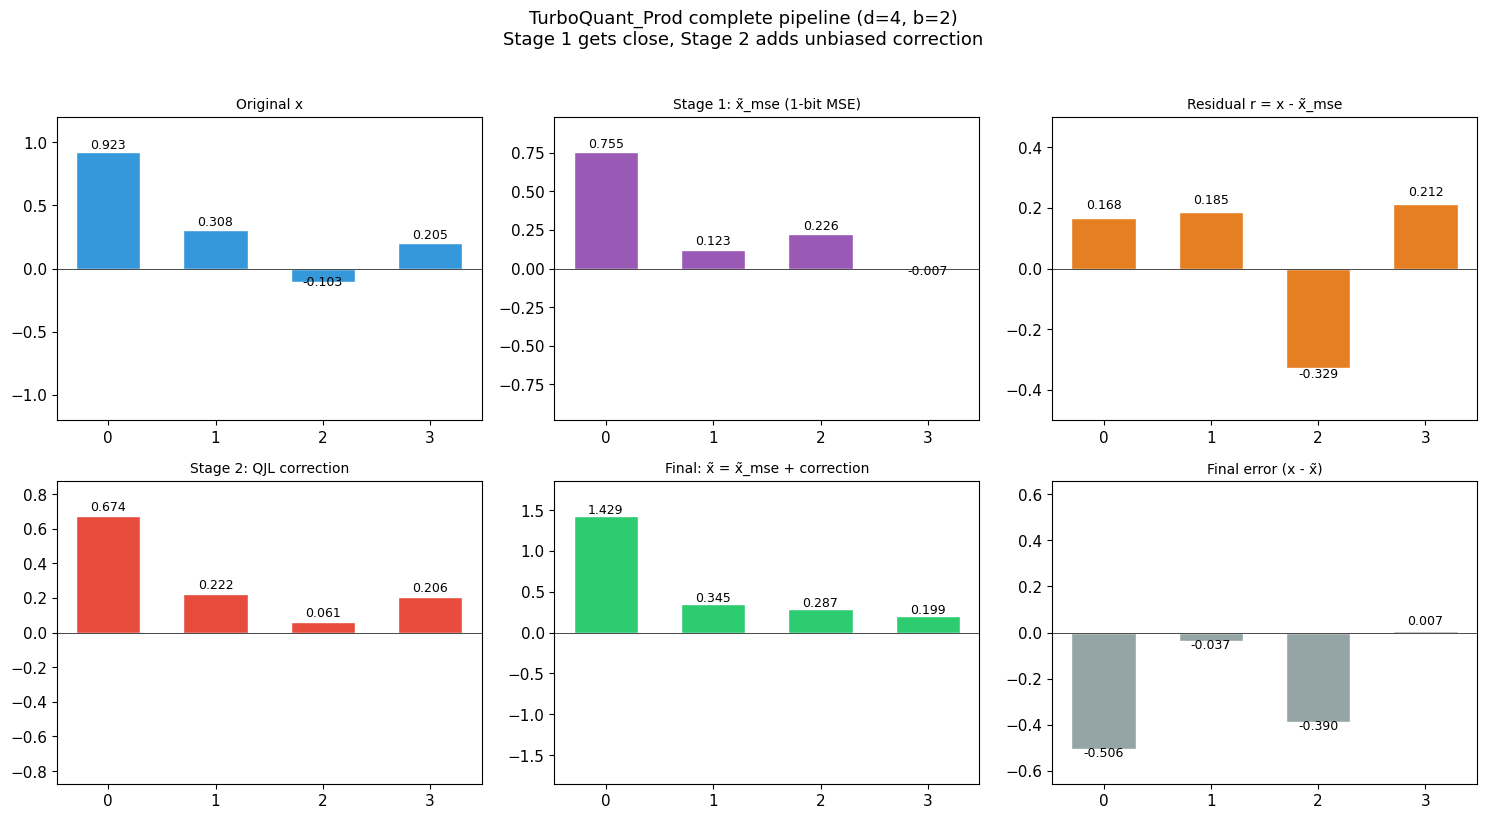

In [16]:
# Visualize all the pieces
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plots = [
    (axes[0,0], x,       'Original x',            '#3498db'),
    (axes[0,1], x_mse,   'Stage 1: x̃_mse (1-bit MSE)', '#9b59b6'),
    (axes[0,2], r,       'Residual r = x - x̃_mse',      '#e67e22'),
    (axes[1,0], x_qjl,   'Stage 2: QJL correction',      '#e74c3c'),
    (axes[1,1], x_prod,  'Final: x̃ = x̃_mse + correction', '#2ecc71'),
    (axes[1,2], x - x_prod, 'Final error (x - x̃)',       '#95a5a6'),
]

for ax, vec, title, color in plots:
    ax.bar(range(d), vec, color=color, edgecolor='white', width=0.6)
    for i, v in enumerate(vec):
        ax.text(i, v + 0.03 * np.sign(v), f'{v:.3f}', ha='center', fontsize=9)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(d))
    ymax = max(0.5, np.max(np.abs(vec)) * 1.3)
    ax.set_ylim(-ymax, ymax)

plt.suptitle(f'TurboQuant_Prod complete pipeline (d={d}, b={b_prod})\n'
             f'Stage 1 gets close, Stage 2 adds unbiased correction',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 9: Verify — QJL Correction Removes Bias

Run many trials and compare the bias between MSE-only and the two-stage Prod version.

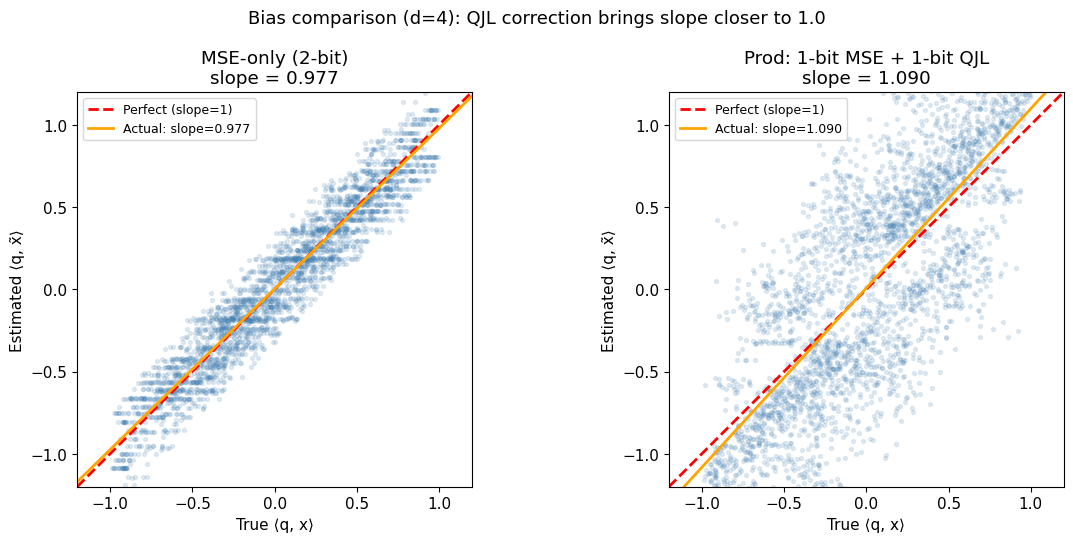

In [17]:
n_trials = 3000
mse_true, mse_est = [], []
prod_true, prod_est = [], []

q = np.random.randn(d)
q = q / np.linalg.norm(q)

# Precompute 1-bit centroids for Prod stage 1
centroids_1b, bounds_1b = lloyd_max_gaussian(2, sigma)
# Precompute 2-bit centroids for MSE-only
centroids_2b, bounds_2b = lloyd_max_gaussian(4, sigma)

for _ in range(n_trials):
    xi = np.random.randn(d)
    xi = xi / np.linalg.norm(xi)
    true_ip = np.dot(q, xi)
    
    # --- MSE-only (2 bit) ---
    yi = Pi @ xi
    idx_i = np.searchsorted(bounds_2b[1:-1], yi)
    xi_mse = Pi.T @ centroids_2b[idx_i]
    mse_true.append(true_ip)
    mse_est.append(np.dot(q, xi_mse))
    
    # --- Prod (1-bit MSE + 1-bit QJL) ---
    idx_s1 = np.searchsorted(bounds_1b[1:-1], yi)
    xi_s1 = Pi.T @ centroids_1b[idx_s1]
    ri = xi - xi_s1
    gi = np.linalg.norm(ri)
    qjl_i = np.sign(S @ ri)
    xi_prod = xi_s1 + gi * np.sqrt(np.pi/2) / d * (S.T @ qjl_i)
    prod_true.append(true_ip)
    prod_est.append(np.dot(q, xi_prod))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, t, e, title in [(axes[0], mse_true, mse_est, 'MSE-only (2-bit)'),
                         (axes[1], prod_true, prod_est, 'Prod: 1-bit MSE + 1-bit QJL')]:
    t, e = np.array(t), np.array(e)
    ax.scatter(t, e, alpha=0.15, s=8, color='steelblue')
    lim = 1.2
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=2, label='Perfect (slope=1)')
    c = np.polyfit(t, e, 1)
    ax.plot([-lim, lim], [c[0]*(-lim)+c[1], c[0]*lim+c[1]],
            'orange', lw=2, label=f'Actual: slope={c[0]:.3f}')
    ax.set_xlabel('True ⟨q, x⟩')
    ax.set_ylabel('Estimated ⟨q, x̃⟩')
    ax.set_title(f'{title}\nslope = {c[0]:.3f}')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.suptitle(f'Bias comparison (d={d}): QJL correction brings slope closer to 1.0', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 10: Mini Search — Finding the Most Similar Vector

A tiny "database" of 8 vectors. Quantize them all, then search with a query.

In [18]:
# Build a tiny database
n_db = 8
db = np.random.randn(n_db, d)
db = db / np.linalg.norm(db, axis=1, keepdims=True)

query = np.array([0.6, 0.5, -0.4, 0.3])
query = query / np.linalg.norm(query)

print(f"Query: {query}")
print(f"\nDatabase ({n_db} vectors, d={d}):")
for i in range(n_db):
    print(f"  db[{i}] = {db[i]}")

# True similarities
true_sims = db @ query
true_rank = np.argsort(-true_sims)

# Quantize each database vector (using Prod)
quant_db = np.zeros_like(db)
for i in range(n_db):
    yi = Pi @ db[i]
    # Stage 1: 1-bit MSE
    idx_i = np.searchsorted(bounds_1b[1:-1], yi)
    xi_s1 = Pi.T @ centroids_1b[idx_i]
    # Stage 2: QJL
    ri = db[i] - xi_s1
    gi = np.linalg.norm(ri)
    qjl_i = np.sign(S @ ri)
    quant_db[i] = xi_s1 + gi * np.sqrt(np.pi/2) / d * (S.T @ qjl_i)

# Quantized similarities
quant_sims = quant_db @ query
quant_rank = np.argsort(-quant_sims)

print(f"\n{'Vec':<6} {'True sim':>10} {'Quant sim':>10} {'True rank':>10} {'Quant rank':>10}")
print("-" * 50)
for i in range(n_db):
    t_rank = np.where(true_rank == i)[0][0] + 1
    q_rank = np.where(quant_rank == i)[0][0] + 1
    marker = " ← best!" if t_rank == 1 else ""
    print(f"db[{i}]  {true_sims[i]:>10.4f} {quant_sims[i]:>10.4f} {t_rank:>10} {q_rank:>10}{marker}")

print(f"\nTrue best match:      db[{true_rank[0]}] (sim = {true_sims[true_rank[0]]:.4f})")
print(f"Quantized best match: db[{quant_rank[0]}] (sim = {quant_sims[quant_rank[0]]:.4f})")
print(f"Correct? {'✓ Yes!' if true_rank[0] == quant_rank[0] else '✗ No — ranking changed'}")

Query: [ 0.647   0.5392 -0.4313  0.3235]

Database (8 vectors, d=4):
  db[0] = [ 0.4156  0.0687  0.5664 -0.7084]
  db[1] = [-0.12   -0.0247 -0.9194 -0.3737]
  db[2] = [-0.4924  0.5739 -0.4278 -0.4951]
  db[3] = [ 0.2945 -0.5828 -0.7461 -0.1303]
  db[4] = [-0.6361 -0.6194  0.252   0.3849]
  db[5] = [ 0.2803  0.3939  0.4409 -0.7562]
  db[6] = [ 0.3868 -0.4548 -0.6418  0.4812]
  db[7] = [-0.6685 -0.6765  0.2448  0.1885]

Vec      True sim  Quant sim  True rank Quant rank
--------------------------------------------------
db[0]     -0.1675     0.2128          6          2
db[1]      0.1847    -0.5367          2          6
db[2]      0.0152    -0.4624          4          5
db[3]      0.1560     0.1483          3          3
db[4]     -0.7297    -1.6441          7          8
db[5]     -0.0411     0.1300          5          4
db[6]      0.4376     0.4373          1          1 ← best!
db[7]     -0.8419    -1.5124          8          7

True best match:      db[6] (sim = 0.4376)
Quantized best m

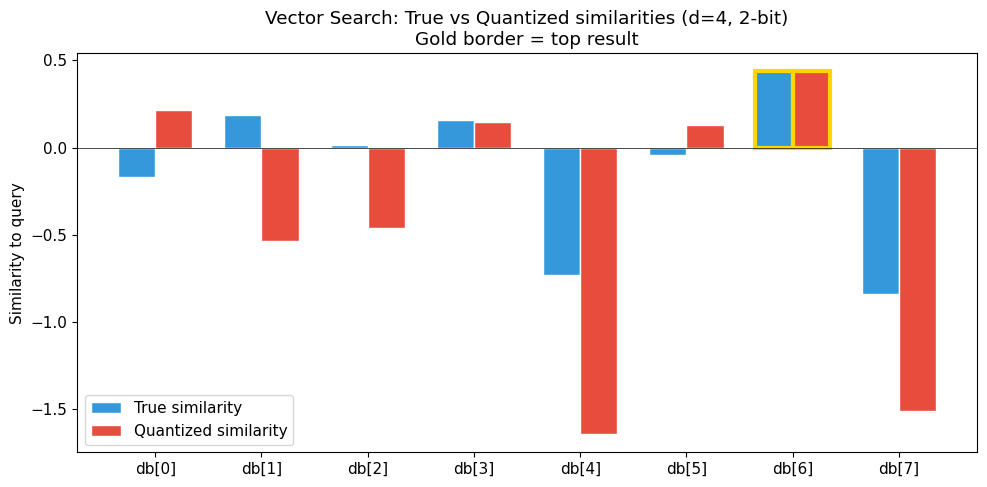

In [19]:
# Visualize the search results
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(n_db)
width = 0.35
bars1 = ax.bar(x_pos - width/2, true_sims, width, label='True similarity', color='#3498db', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, quant_sims, width, label='Quantized similarity', color='#e74c3c', edgecolor='white')

# Highlight the best match
ax.bar(true_rank[0] - width/2, true_sims[true_rank[0]], width,
       color='#3498db', edgecolor='gold', linewidth=3)
ax.bar(quant_rank[0] + width/2, quant_sims[quant_rank[0]], width,
       color='#e74c3c', edgecolor='gold', linewidth=3)

ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'db[{i}]' for i in range(n_db)])
ax.set_ylabel('Similarity to query')
ax.set_title(f'Vector Search: True vs Quantized similarities (d={d}, {b_prod}-bit)\n'
             f'Gold border = top result')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

With just d=4 and b=2 bits, you've traced every number through:

1. **Rotation** — Π scrambles the vector into a predictable distribution
2. **Quantization** — Each coordinate snaps to the nearest centroid (just 2 bits!)
3. **Dequantization** — Look up centroids, rotate back
4. **Bias problem** — MSE quantizer shrinks dot products (slope < 1)
5. **Two-stage fix** — (b-1)-bit MSE + 1-bit QJL = unbiased dot products
6. **Search** — Even with tiny vectors and aggressive compression, rankings are preserved

Now go back to the main notebook and the high-dimensional results will make intuitive sense!